In [1]:
import numpy as np
from pillow_lab_rotation import lds
from pillow_lab_rotation.simulate import LDSSim, generate_gaussian_inputs, generate_pulsatile_inputs
import matplotlib.pyplot as plt
from importlib import reload

plt.style.use('../JS.mplstyle')

### MSE between fit parameters and ground-truth parameters should go down monotonically with the amount of data (LDS with inputs)

In [2]:
reload(lds)

xdim, ydim, udim = 3, 10, 3
T = 50

simulation = LDSSim(xdim, ydim, udim=udim, feedthrough=False)
np.random.seed(42)
simulation.create_params()

trial_list = [50, 100, 200, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000]
U_all = generate_pulsatile_inputs(trial_list[-1], T, udim)
U_all = generate_gaussian_inputs(trial_list[-1], T, udim)
X_all, Y_all = simulation.simulate(T, trial_list[-1], inputs=U_all)

A_true, C_true, Q_true, Q0_true, mu0_true, R_true, B_true = simulation.get_params()

A_loss = []
C_loss = []
Q_loss = []
R_loss = []
B_loss = []
D_loss = []

np.random.seed(0)
model = lds.LinearDynamicalSystem(xdim, ydim, udim=udim, feedthrough=False)

for n_trials in trial_list:
    print(f'Fitting with {n_trials} trials')
    model.A = A_true.copy()
    model.C = C_true.copy()
    model.Q = Q_true.copy()
    model.Q0 = Q0_true.copy()
    model.mu0 = mu0_true.copy()
    model.R = R_true.copy()
    model.B = B_true.copy()

    Y = Y_all[:n_trials]
    U = U_all[:n_trials]
    model.fit(Y, inputs=U, verbose=False)

    C_prime = model.C
    H = np.linalg.inv(C_prime.T @ C_prime) @ C_prime.T @ C_true
    H_inv = np.linalg.inv(H)

    A_rec = H_inv @ model.A @ H
    C_rec = model.C @ H
    Q_rec = H_inv @ model.Q @ H_inv.T
    B_rec = H_inv @ model.B

    A_loss.append(np.mean((A_rec - A_true)**2))
    C_loss.append(np.mean((C_rec - C_true)**2))
    Q_loss.append(np.mean((Q_rec - Q_true)**2))
    R_loss.append(np.mean((model.R - R_true)**2))
    B_loss.append(np.mean((B_rec - B_true)**2))

Fitting with 50 trials


KeyboardInterrupt: 

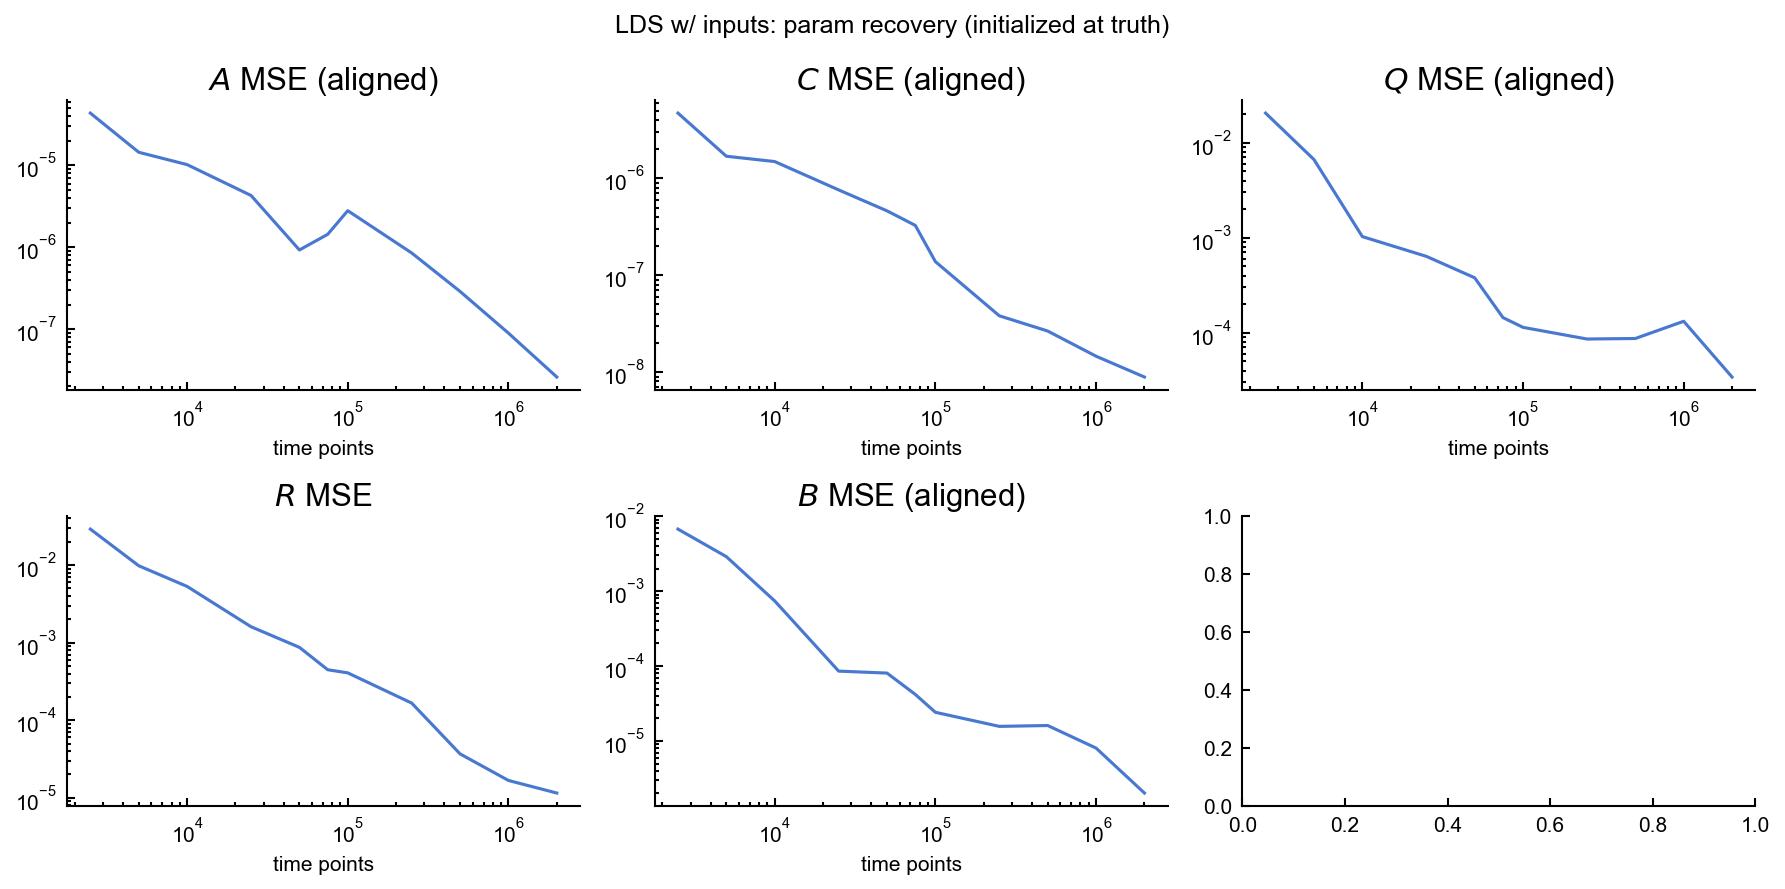

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
titles = ['$A$ MSE (aligned)', '$C$ MSE (aligned)', '$Q$ MSE (aligned)',
          '$R$ MSE', '$B$ MSE (aligned)']
losses = [A_loss, C_loss, Q_loss, R_loss, B_loss]

for ax, title, loss in zip(axes.flat, titles, losses):
    ax.plot(T * np.array(trial_list), loss)
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time points')

fig.suptitle('LDS w/ inputs: param recovery (initialized at truth)')
fig.tight_layout()

### Multiple datasets: confirm downward trend is consistent

In [4]:
reload(lds)

n_datasets = 5
xdim, ydim, udim = 3, 7, 3
T = 50
trial_list = [50, 100, 200, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000]
param_names = ['A', 'C', 'Q', 'R', 'B']

# Store losses: dict of param_name -> (n_datasets, len(trial_list))
all_losses = {name: np.zeros((n_datasets, len(trial_list))) for name in param_names}

for d in range(n_datasets):
    print(f'--- Dataset {d+1}/{n_datasets} ---')
    sim = LDSSim(xdim, ydim, udim=udim, feedthrough=False)
    np.random.seed(d * 100)
    sim.create_params()

    U_all = generate_gaussian_inputs(trial_list[-1], T, udim)
    X_all, Y_all = sim.simulate(T, trial_list[-1], inputs=U_all)

    A_true, C_true, Q_true, Q0_true, mu0_true, R_true, B_true = sim.get_params()

    model = lds.LinearDynamicalSystem(xdim, ydim, udim=udim, feedthrough=False)

    for j, n_trials in enumerate(trial_list):
        print(f'  Fitting with {n_trials} trials')
        model.A = A_true.copy()
        model.C = C_true.copy()
        model.Q = Q_true.copy()
        model.Q0 = Q0_true.copy()
        model.mu0 = mu0_true.copy()
        model.R = R_true.copy()
        model.B = B_true.copy()

        Y = Y_all[:n_trials]
        U = U_all[:n_trials]
        model.fit(Y, inputs=U, verbose=False)

        C_prime = model.C
        H = np.linalg.inv(C_prime.T @ C_prime) @ C_prime.T @ C_true
        H_inv = np.linalg.inv(H)

        A_rec = H_inv @ model.A @ H
        C_rec = model.C @ H
        Q_rec = H_inv @ model.Q @ H_inv.T
        B_rec = H_inv @ model.B

        all_losses['A'][d, j] = np.mean((A_rec - A_true)**2)
        all_losses['C'][d, j] = np.mean((C_rec - C_true)**2)
        all_losses['Q'][d, j] = np.mean((Q_rec - Q_true)**2)
        all_losses['R'][d, j] = np.mean((model.R - R_true)**2)
        all_losses['B'][d, j] = np.mean((B_rec - B_true)**2)

--- Dataset 1/5 ---
  Fitting with 50 trials
  Fitting with 100 trials
  Fitting with 200 trials
  Fitting with 500 trials
  Fitting with 1000 trials
  Fitting with 1500 trials
  Fitting with 2000 trials
  Fitting with 5000 trials
  Fitting with 10000 trials
  Fitting with 20000 trials
  Fitting with 40000 trials
--- Dataset 2/5 ---
  Fitting with 50 trials
  Fitting with 100 trials
  Fitting with 200 trials
  Fitting with 500 trials
  Fitting with 1000 trials
  Fitting with 1500 trials
  Fitting with 2000 trials
  Fitting with 5000 trials
  Fitting with 10000 trials
  Fitting with 20000 trials
  Fitting with 40000 trials
--- Dataset 3/5 ---
  Fitting with 50 trials
  Fitting with 100 trials
  Fitting with 200 trials
  Fitting with 500 trials
  Fitting with 1000 trials
  Fitting with 1500 trials
  Fitting with 2000 trials
  Fitting with 5000 trials
  Fitting with 10000 trials
  Fitting with 20000 trials
  Fitting with 40000 trials
--- Dataset 4/5 ---
  Fitting with 50 trials
  Fitting 

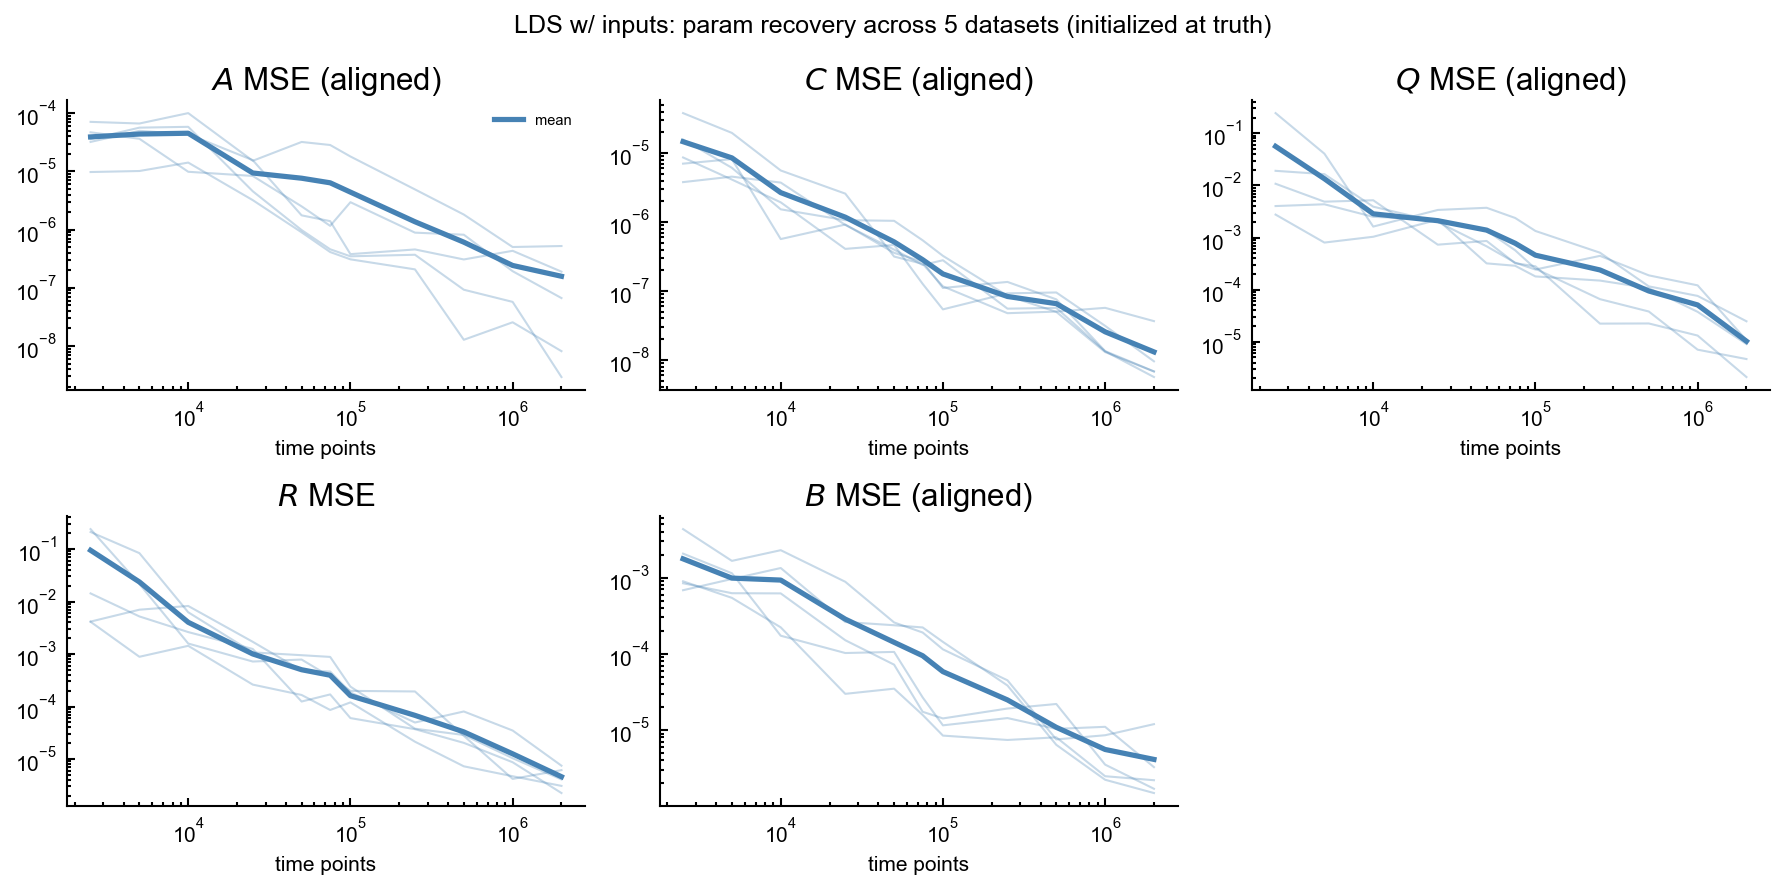

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
titles = ['$A$ MSE (aligned)', '$C$ MSE (aligned)', '$Q$ MSE (aligned)',
          '$R$ MSE', '$B$ MSE (aligned)']
time_points = T * np.array(trial_list)

for ax, title, name in zip(axes.flat, titles, param_names):
    losses = all_losses[name]
    # Individual dataset traces
    for d in range(n_datasets):
        ax.plot(time_points, losses[d], color='steelblue', alpha=0.3, linewidth=1)
    # Mean across datasets
    ax.plot(time_points, losses.mean(axis=0), color='steelblue', linewidth=2.5, label='mean')
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time points')

axes.flat[0].legend()
axes.flat[-1].set_visible(False)
fig.suptitle(f'LDS w/ inputs: param recovery across {n_datasets} datasets (initialized at truth)')
fig.tight_layout()